# Lorenz-63: particle filter

## 1. Overview

This tutorial applies a bootstrap particle filter (PF) with systematic
resampling to the chaotic Lorenz-63 model with fully observed, noisy
observations. It follows `docs/notebook_spec.md`; the paired CLI script is
`examples/scripts/l63_pf.py`.

## 2. Model

The Lorenz-63 model is the three-variable chaotic system

$$
\dot{x} = \sigma (y - x), \qquad
\dot{y} = x (r - z) - y, \qquad
\dot{z} = x y - b z,
$$

with the standard chaotic parameters $\sigma = 10$, $r = 28$, $b = 8/3$
(`da.l63.lorenz63`). The state is $x_k = (x, y, z) \in \mathbb{R}^{3}$.
The discrete forecast map $M$ integrates the system with fourth-order
Runge-Kutta (`da.scheme.rk4`) using time step $\delta t$ over one
assimilation window of $n_{\mathrm{obs}}$ steps, i.e.
$\Delta t = n_{\mathrm{obs}}\, \delta t$:

$$
x_k = M(x_{k-1}) = \Psi_{\delta t}^{n_{\mathrm{obs}}}(x_{k-1}).
$$

## 3. Observation

The full state is observed with additive Gaussian noise every assimilation
window:

$$
y_k = H x_k + \varepsilon_k, \qquad
H = I_3, \qquad
\varepsilon_k \sim N(0, R), \quad R = r_0^2 I_3 .
$$

The observation-noise scale used for RMSE comparison is
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} = r_0$
(see `docs/notebook_spec.md`).

## 4. DA method

The **bootstrap particle filter** represents the posterior by $m$ weighted
particles $\{x^{(i)}, w^{(i)}\}$.

**Forecast step:** each particle is propagated by the model,
$x_k^{(i)} = M(x_{k-1}^{(i)})$, followed by small additive noise
(`add_inflation`) to prevent degeneracy.

**Analysis step:** the weights are updated with the Gaussian likelihood

$$
w_k^{(i)} \propto w_{k-1}^{(i)}
\exp\!\Big( -\tfrac{1}{2}\, \| y_k - H x_k^{(i)} \|_{R^{-1}}^2 \Big),
$$

and the particles are resampled (systematic resampling) whenever the
effective sample size
$N_{\mathrm{eff}} = 1 / \sum_i (w^{(i)})^2$
falls below a threshold ($N_{\mathrm{thr}} \cdot m$). The state estimate is
the weighted mean $\hat{x}^a = \sum_i w^{(i)} x^{(i)}$.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| assimilation cycles | | 400 |
| observation noise variance | $r_0^2$ | 2.0 |
| particles | $m$ | 40 |
| additive inflation | | 0.02 |
| resampling threshold | $N_{\mathrm{thr}}$ | 0.5 |
| initial ensemble spread | | 0.8 |
| random seed | | 7 |

The script exposes `--cycles`, `--particles`, `--obs-noise-variance`,
`--add-inflation`, `--dt`, `--obs-interval`, and `--seed`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l63 import lorenz63
from da.scheme import rk4
from da.pf import ParticleFilter

def l63_step(x, dt):
    return rk4(lorenz63, 0.0, np.asarray(x), (), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l63_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))

dt, obs_interval, cycles, seed = 0.01, 5, 400, 7
m = 40
H = np.eye(3)
R = 2.0 * np.eye(3)

## 6. Truth and observations

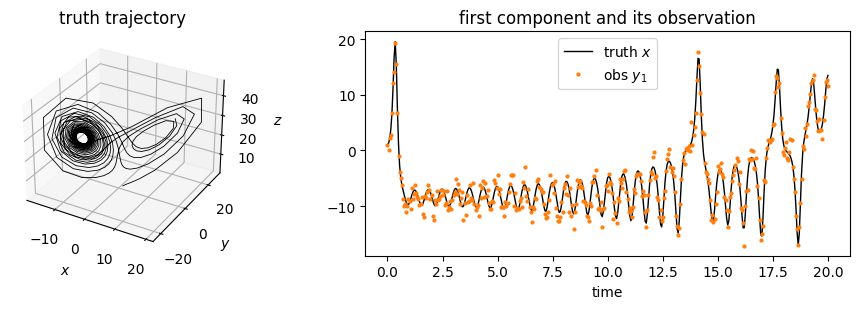

In [2]:
rng = np.random.default_rng(seed)
x = np.array([1.0, 1.0, 1.0])
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(3), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(3), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

fig = plt.figure(figsize=(10, 3.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*truth.T, lw=0.6, color="k")
ax.set_title("truth trajectory")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax = fig.add_subplot(1, 2, 2)
ax.plot(t, truth[:, 0], color="k", lw=1, label="truth $x$")
ax.plot(t, obs[:, 0], ".", color="tab:orange", ms=4, label="obs $y_1$")
ax.set_xlabel("time")
ax.legend()
ax.set_title("first component and its observation")
fig.tight_layout()

## 7. Assimilation results

The estimate is the weighted particle mean `filt.W @ filt.X`.

In [3]:
X0 = truth[0] + np.array([1.0, -1.0, 0.5]) + 0.8 * rng.standard_normal((m, 3))
filt = ParticleFilter(l63_step, lambda x: H @ x, R, add_inflation=0.02, N_thr=0.5)
filt.initialize(X0)

means = [filt.W @ filt.X]
rmses = [rmse(means[0], truth[0])]
for k in range(1, cycles + 1):
    for _ in range(obs_interval):
        filt.forecast(dt)
    filt.update(obs[k])
    means.append(filt.W @ filt.X)
    rmses.append(rmse(means[-1], truth[k]))
means, rmses = np.asarray(means), np.asarray(rmses)

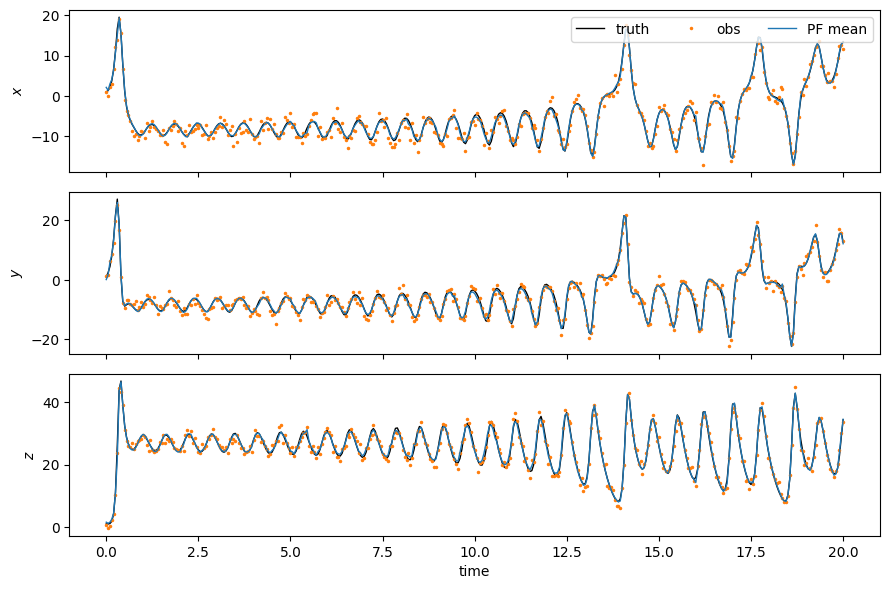

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, truth[:, i], color="k", lw=1, label="truth")
    ax.plot(t, obs[:, i], ".", color="tab:orange", ms=3, label="obs")
    ax.plot(t, means[:, i], color="tab:blue", lw=1, label="PF mean")
    ax.set_ylabel(["$x$", "$y$", "$z$"][i])
axes[0].legend(ncol=3, loc="upper right")
axes[-1].set_xlabel("time")
fig.tight_layout()

## 8. RMSE

observation noise scale: 1.414
mean RMSE (2nd half): 0.408


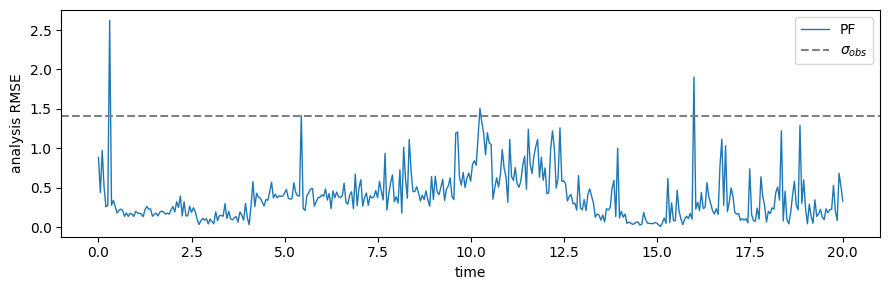

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, rmses, color="tab:blue", lw=1, label="PF")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"mean RMSE (2nd half): {rmses[half:].mean():.3f}")

## 9. Summary

With only $m = 40$ particles the bootstrap PF keeps the analysis RMSE
around $0.4$, well below $\sigma_{\mathrm{obs}} \approx 1.41$. In this
low-dimensional, fully observed setting a modest particle number suffices;
occasional RMSE spikes correspond to lobe transitions where the particle
cloud momentarily spreads.